In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sns.set_theme(style='whitegrid')

# load price history
data_folder = '../data/'
for file in os.listdir(data_folder):
    if 'price_history_full' in file:
        df = pd.read_csv(data_folder + file)

launch_ref = pd.read_csv('../data/official_launch_prices.csv')

df = df.merge(launch_ref, on='submodel_name')
df['official_premiere_date'] = pd.to_datetime(df['official_premiere_date'])
df['datetime'] = pd.to_datetime(df['datetime'])
df['days_since_launch'] = (df['datetime'] - df['official_premiere_date']).dt.days
df = df[df['days_since_launch'] > 0]
df['NEW'] = df['new_price'] * 100
df = df.drop('new_price', axis=1)
df['price_pct_of_launch'] = round(df['NEW'] / df['official_launch_price'] * 100, 1)
df['days_rounded'] = (df['days_since_launch'] / 7).round() * 7
df['tier'] = df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
df['tier'] = df['tier'].replace('', 'Base')

# load monthly sold
ms_df = pd.read_csv('../data/monthly_sold_full.csv')
ms_df = ms_df.merge(launch_ref, on='submodel_name', how='left')
ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])
del ms_df['premiere_date']
ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]
ms_df['tier'] = ms_df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')

# price decay dataframes
base_apple_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple') & (df['generation_name'] != 'iPhone 17')]
base_apple_decay_df = base_apple_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_samsung_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Samsung')]
base_samsung_decay_df = base_samsung_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_google_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Google')]
base_google_decay_df = base_google_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_combined_df = df[df['tier'] == 'Base']
all_brands_decay_df = base_combined_df.groupby(['brand', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

grouped_generation_decay_df = df.groupby(['submodel_name', 'generation_name', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()
iphone13_decay_df = grouped_generation_decay_df[grouped_generation_decay_df['generation_name'] == 'iPhone 13']
 
 
 
 
# 1-year retention
yearly_change_df = df[(df['days_rounded'] > 330) & (df['days_rounded'] < 380)]
retention_1yr_df = yearly_change_df.groupby('generation_name').agg(
    price_retention=('price_pct_of_launch', 'mean'),
    brand=('brand', 'first')
).reset_index().sort_values('price_retention', ascending=False)

brand_retention = retention_1yr_df.groupby('brand')['price_retention'].mean()
apple_retention = brand_retention['Apple']
samsung_retention = brand_retention['Samsung']
google_retention = brand_retention['Google']

grade_means = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple')].groupby('product_grade')['price_pct_of_launch'].mean()
renewed_premium_premium = grade_means['Renewed Premium'] - grade_means['Renewed']

# sales rank dataframes
apple_base_rank_df = ms_df[(ms_df['tier'] == 'Base') & (ms_df['brand'] == 'Apple') & (ms_df['monthly_sold'] >= 0)]
apple_base_rank_df = apple_base_rank_df.groupby(['generation_name', 'days_rounded'])['monthly_sold'].mean().reset_index()

iphone13_rank_df = ms_df[ms_df['generation_name'] == 'iPhone 13']
iphone13_rank_df = iphone13_rank_df.groupby(['submodel_name', 'days_rounded'])['monthly_sold'].mean().reset_index()

iphone15_rank_df = ms_df[ms_df['generation_name'] == 'iPhone 15']
iphone15_rank_df = iphone15_rank_df.groupby(['submodel_name', 'days_rounded'])['monthly_sold'].mean().reset_index()


rank_dates_gen_df = (ms_df.set_index('datetime')
    .groupby(['generation_name', 'brand', 'tier'])
    .resample('W')['monthly_sold'].mean().reset_index())
rank_dates_gen_df['monthly_sold'] = rank_dates_gen_df.groupby('generation_name')['monthly_sold'].ffill()
apple_base_rank_dates_df = rank_dates_gen_df[
    (rank_dates_gen_df['tier'] == 'Base') &
    (rank_dates_gen_df['brand'] == 'Apple') &
    (rank_dates_gen_df['monthly_sold'] >= 0)
]

rank_dates_sub_df = (ms_df.set_index('datetime')
    .groupby(['submodel_name', 'brand', 'generation_name'])
    .resample('W')['monthly_sold'].mean().reset_index())
rank_dates_sub_df['monthly_sold'] = rank_dates_sub_df.groupby('generation_name')['monthly_sold'].ffill()
iphone13_rank_dates_df = rank_dates_sub_df[rank_dates_sub_df['generation_name'] == 'iPhone 13']
iphone15_rank_dates_df = rank_dates_sub_df[rank_dates_sub_df['generation_name'] == 'iPhone 15']


#Launch ref tiers added for flagship vs base official launch prices comaprison
gen_lookup = df[['submodel_name', 'generation_name', 'brand']].drop_duplicates()
launch_ref = launch_ref.merge(gen_lookup, on='submodel_name', how='left')
launch_ref['tier'] = launch_ref.apply(lambda row: row['submodel_name'].replace(str(row['generation_name']), '').strip(), axis=1)
launch_ref['tier'] =  launch_ref['tier'].replace('', 'Base')

launch_ref['official_premiere_date'] = pd.to_datetime(launch_ref['official_premiere_date'])
base_launch_ref = launch_ref[launch_ref['tier'] == 'Base']
flagship_launch_ref = launch_ref[(launch_ref['tier'] == 'Pro Max') | (launch_ref['tier'] == 'Ultra') | (launch_ref['tier'] == 'Pro XL') | (launch_ref['tier'] == 'Ultra') | ((launch_ref['tier'] == 'Pro') & (launch_ref['brand'] == 'Google'))]



# Amazon Renewed Phone Price Analysis

Methodology & Dataset

Source: Real price data extracted via the Keepa API.
Market: Amazon US (Refurbished / Secondary Market).
Scope: 3 major brands (Apple, Samsung, Google) across 63 submodels.
Volume: Roughly 878,000 weekly price records spanning from 2019 to 2026.

It starts with a macro-level comparison between brands, followed by a deep dive into iPhones.

The central question is pretty simple: once a phone hits the secondary market, how fast does
it lose value, and does it depend on the brand, the model tier, or the time of year? Are there any observable patterns and relations between the brands and submodels?

**A few notes**

Data was fetched via the Keepa API around February 2026, stored in a local PostgreSQL database, and explored using SQL aggregations and views and I also created some data visualizations in Power BI.

Then I had a break as I focused on different projects, but at the beginning of May I decided the project will instead be a Python-focused analysis, which will become one of my portfolio projects, as well as a perfect fit for Crappy Data Python for DA course projects.

Roughly 70–80% of the project timeline was dedicated to iterative EDA, testing different aggregation levels, mapping edge cases, adjusting my choices and handling different issues, with a few setbacks as well.

In the end, I've opted for relative values (% of the launch price vs raw $), but I'm also thinking about including the latter in my analysis.

Some of the challenges I've encountered:

- Each product variant (e.g. iPhone 14 128GB Red Renewed Premium) had its own ASIN code and data tracked only for that particular model, storage size and color. I had to identify that and really consider how to aggregate data
- Datetimes from the API were given with a custom epoch - number of minutes from 2011-01-01 (so called KeepaTime)
- Price tracking history had gaps between the premiere and the actual tracking - this is most likely due to the fact that we're tracking the secondary market
- Price values were divided by 100
- Monthly_sold shows a sales rank rather than the number of goods sold
- Actual sales volume data was omitted, as the available API metrics proved highly imprecise, offering only broad categorical ranges rather than concrete numbers. It was a frustrating decision, but omitting it was the only logical choice to keep the findings reliable

The analysis strictly covers Amazon Renewed listings. For Apple, this captures the full secondary market on Amazon US. For Samsung and Google, New and Renewed listings are separated where relevant.

Launch prices were manually sourced from official press releases using the mean price across all storage tiers (e.g., iPhone 16 Pro reference price is set at $1,224).

The most recent releases (e.g., iPhone 17) were omitted from price decay models due to insufficient data history.

---
## Project Overview

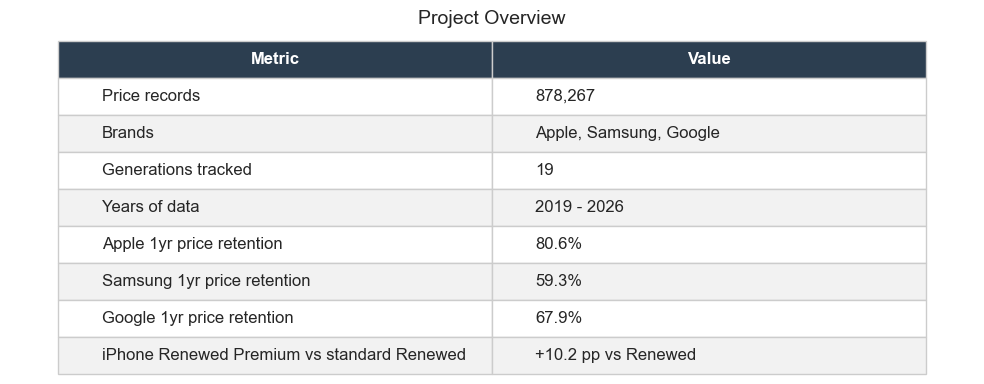

In [2]:
kpi_data = [
    ['Price records', '878,267'],
    ['Brands', 'Apple, Samsung, Google'],
    ['Generations tracked', str(df['generation_name'].nunique())],
    ['Years of data', '2019 - 2026'],
    ['Apple 1yr price retention', f'{round(apple_retention, 1)}%'],
    ['Samsung 1yr price retention', f'{round(samsung_retention, 1)}%'],
    ['Google 1yr price retention', f'{round(google_retention, 1)}%'],
    ['iPhone Renewed Premium vs standard Renewed', f'+{round(renewed_premium_premium, 1)} pp vs Renewed'],
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=kpi_data,
    colLabels=['Metric', 'Value'],
    cellLoc='left',
    loc='center',
    colWidths=[0.45, 0.45]
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('white')

plt.title('Project Overview', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


---
# Price Decay analysis

Each chart below shows price as a percentage of the official launch price over time.
100% means the phone is still at its launch price on the Renewed market, 50% means it's
lost half its value. The x-axis shows days since launch so models can be compared at the
same point in their lifecycle regardless of when they were released.

## Official launch prices
These launch prices were calculated as mean of all relevant memory sizes for a given submodel.

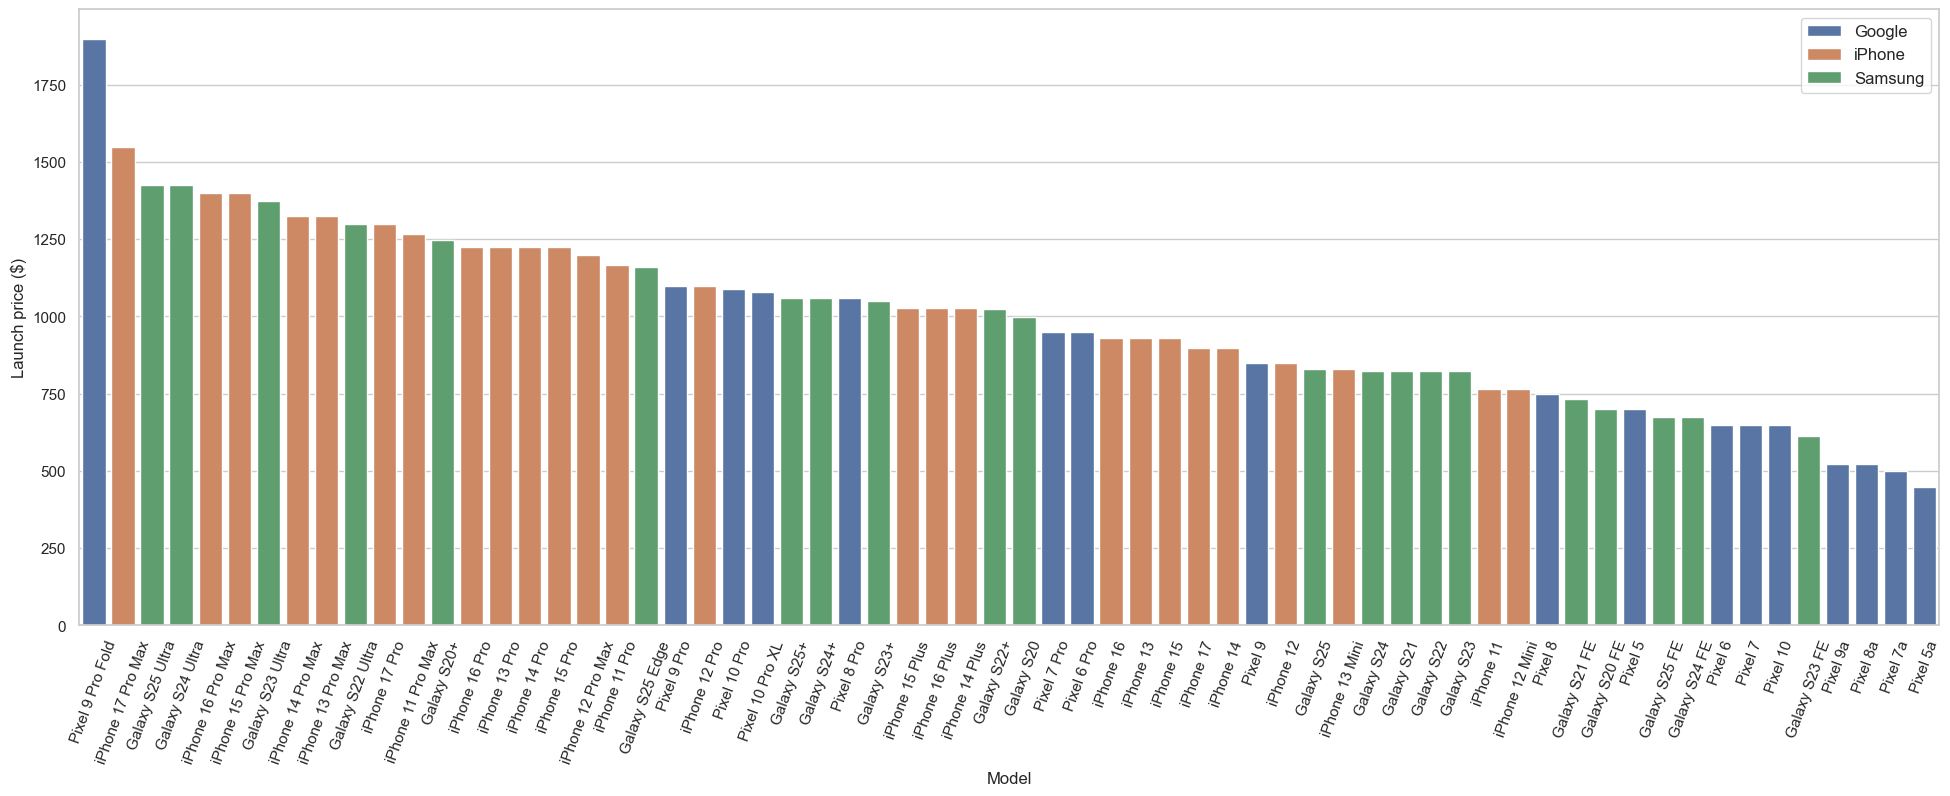

In [3]:
launch_ref['brand'] = launch_ref['submodel_name'].str.split().str[0]
launch_ref['brand'] = launch_ref['brand'].replace(['Pixel', 'Galaxy'], ['Google', 'Samsung'])
launch_ref = launch_ref.sort_values(by = 'official_launch_price', ascending = False)


plt.subplots(figsize = (24, 8))
launch_price_chart = sns.barplot(
    data = launch_ref,
    x = 'submodel_name',
    y = 'official_launch_price',
    hue = 'brand'
)

plt.legend(loc = 'upper right', fontsize = 12)
plt.xticks(rotation = 70)
plt.xlabel('Model')
plt.ylabel('Launch price ($)')
plt.show()

Below is a comparison of the official launch prices across all brands. The first chart focuses on base models (e.g., iPhone 15, Samsung Galaxy S22, Google Pixel 6), while the second highlights flagship submodels (iPhone Pro Max, Samsung Galaxy Ultra, Google Pixel Pro).

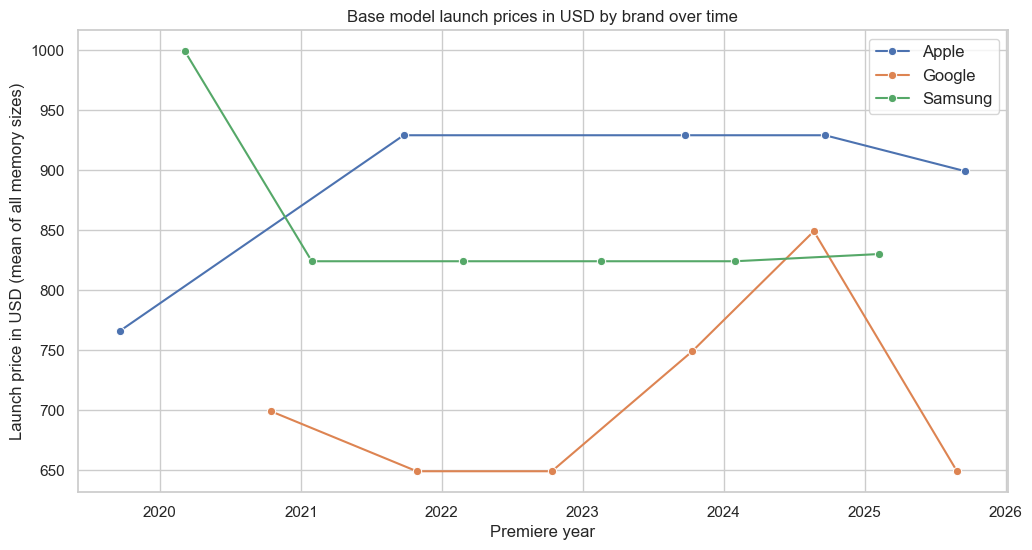

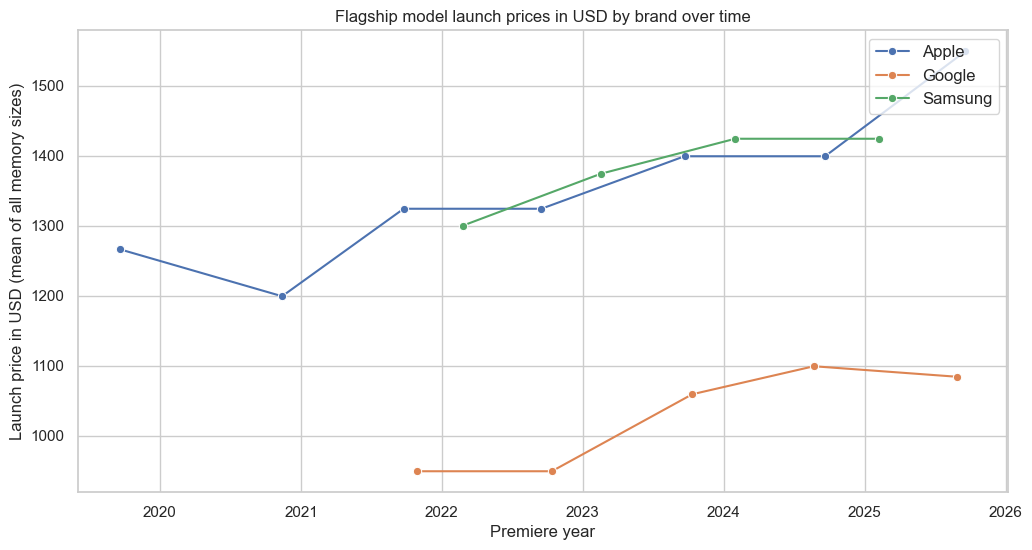

In [4]:


plt.subplots(figsize = (12, 6))
base_launch_chart = sns.lineplot(
    data = base_launch_ref,
    x = 'official_premiere_date',
    y = 'official_launch_price',
    hue = 'brand',
    marker = 'o'
)
plt.legend(loc = 'upper right', fontsize = 12)
plt.xlabel('Premiere year')
plt.ylabel('Launch price in USD (mean of all memory sizes)')
plt.title('Base model launch prices in USD by brand over time')
plt.show()


plt.subplots(figsize = (12, 6))
flagship_launch_chart = sns.lineplot(
    data = flagship_launch_ref,
    x = 'official_premiere_date',
    y = 'official_launch_price',
    hue = 'brand',
    marker = 'o'
)
plt.legend(loc = 'upper right', fontsize = 12)
plt.xlabel('Premiere year')
plt.ylabel('Launch price in USD (mean of all memory sizes)')
plt.title('Flagship model launch prices in USD by brand over time')
plt.show()
plt.show()


Google consistently positions itself as the most budget-friendly choice. Across both flagship and base tiers, Google smartphones are generally priced about 20% lower than their competitors.

Samsung and Apple compete directly at the top of the market, Apple's base models are typically about 10% more expensive than Samsung's base models, but that gap disappears at the premium level. Samsung’s Ultra models are priced almost identically to Apple’s Pro Max variants.

**Base models combined for all brands**

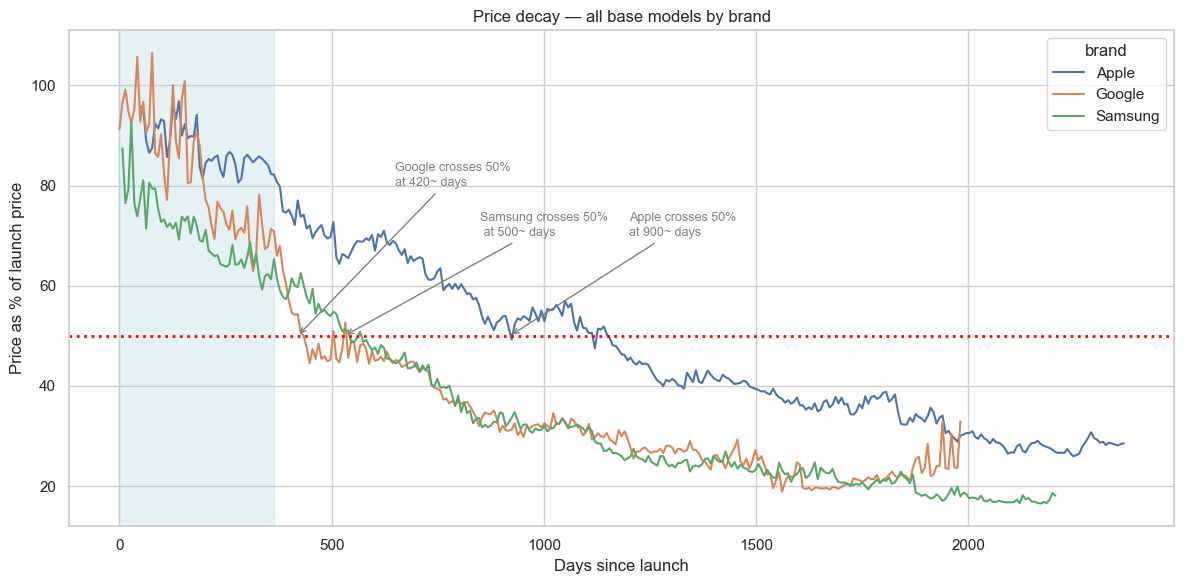

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1d = sns.lineplot(data=all_brands_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='brand', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay — all base models by brand')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
plt.tight_layout()

#annotations
plt.axvspan(0, 365, alpha = 0.33, color = 'lightblue', label = 'First year')
plt.annotate(
    'Samsung crosses 50%\n at 500~ days',
    xy=(530, 50),
    xytext=(850, 70),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)
plt.annotate(
    'Apple crosses 50%\nat 900~ days',
    xy=(920, 50),
    xytext=(1200, 70),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)
plt.annotate(
    'Google crosses 50%\nat 420~ days',
    xy=(420, 50),
    xytext=(650, 80),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)
plt.show()


The light blue shaded area highlights the first year after launch.

Apple phones are the last to hit the 50% mark, getting there at around 900 days after launch.
Samsung reaches it at roughly 500 days, Google at around 420 days. Apple also has the highest
price floor, stabilising at 26-28% of launch price after about 2000 days. Samsung bottoms out
around 16-17% and Google around 20%.

**Apple base models by generation**

iPhones on Amazon are sold as Renewed or Renewed Premium only. Solid lines are standard Renewed,
dashed lines are Renewed Premium. iPhone 17 is exclude (too little data at this point).

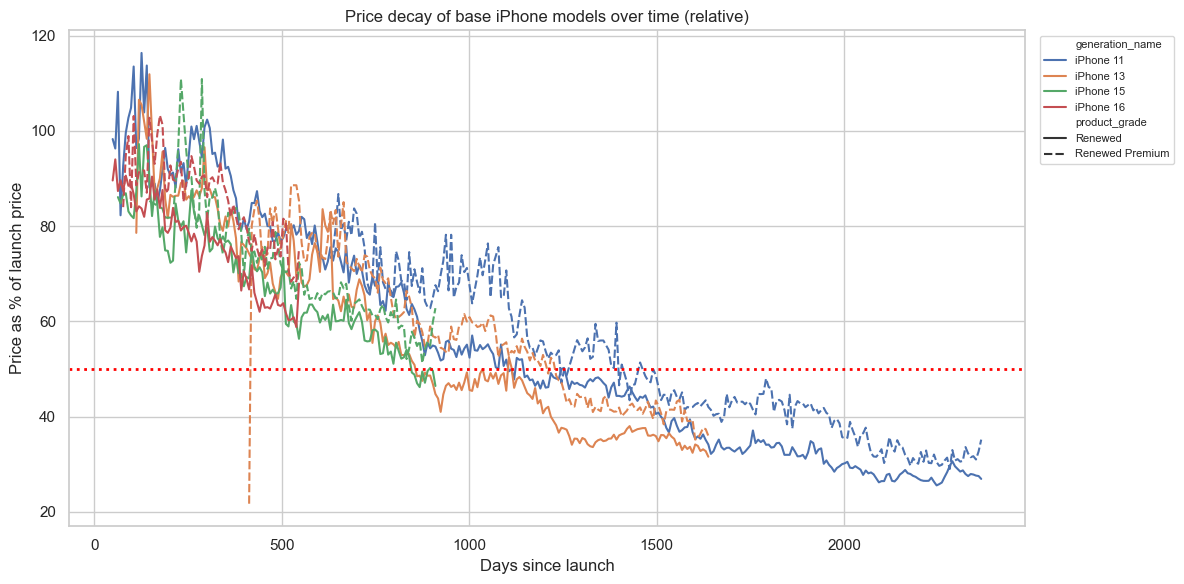

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1 = sns.lineplot(data=base_apple_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', style='product_grade', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base iPhone models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


Renewed Premium consistently sits above the standard Renewed curve for the same generation.
The gap appears early and stays fairly stable throughout the lifecycle, which suggests buyers
pay a persistent condition premium regardless of how old the phone gets. The exact difference
varies by generation but averages around 10.2 percentage points.

**Samsung base models by generation**

Note: product_grade distinction was irrelevant here, as there were only Renewed sales with maybe one exception.

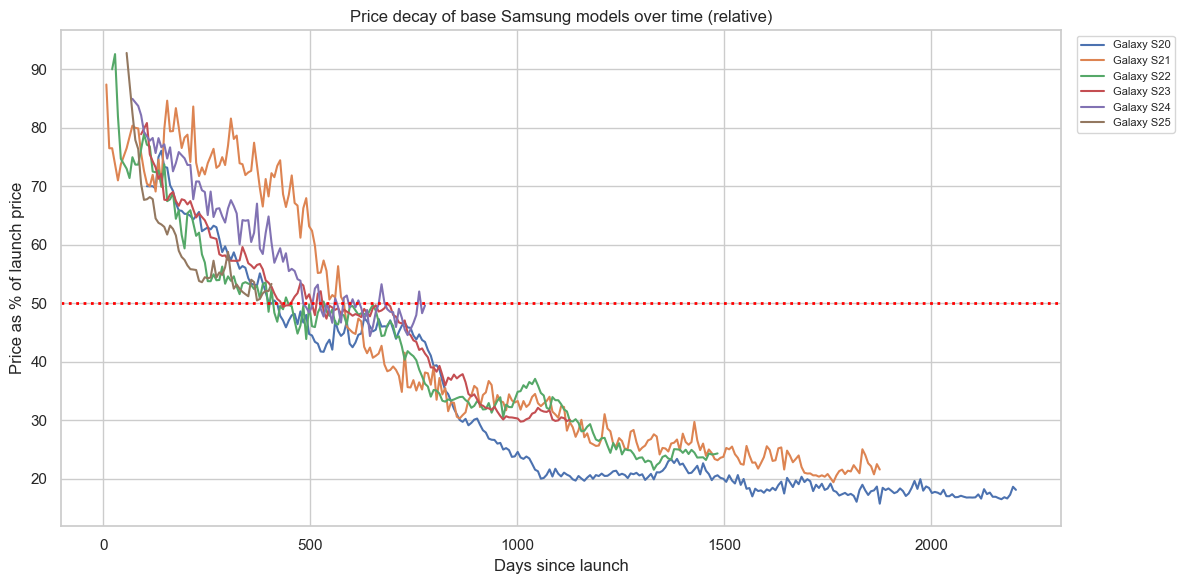

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1b = sns.lineplot(data=base_samsung_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base Samsung models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


**Google Pixel price decay of base models by generation**


Note: as with Samsung, product_grade distinction was irrelevant here, as there were only Renewed sales with a few exceptions.

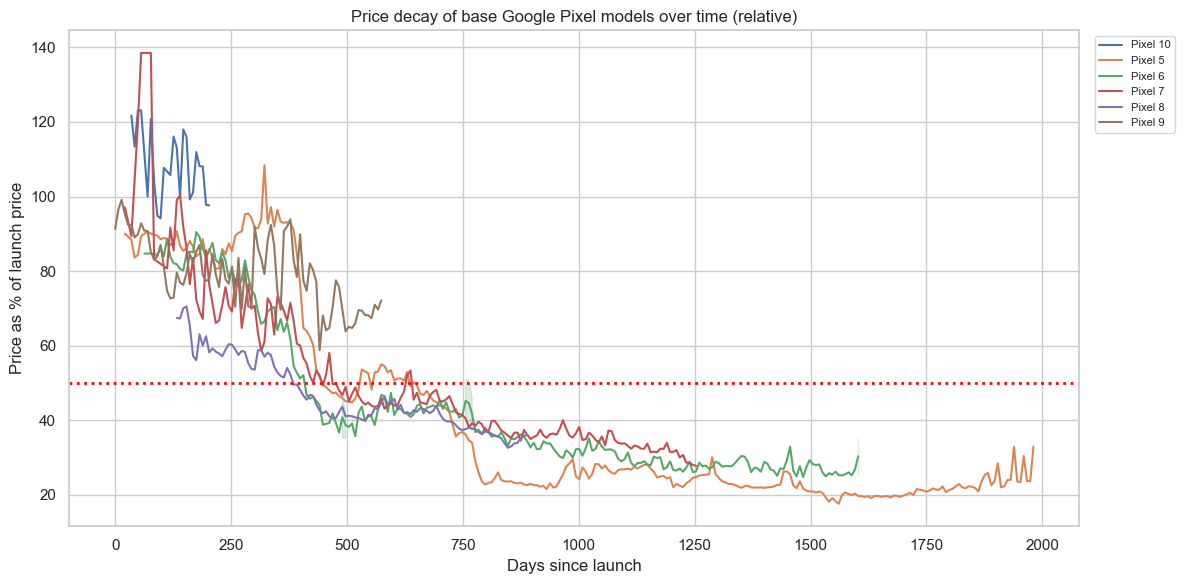

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1c = sns.lineplot(data=base_google_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base Google Pixel models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


**Within a generation iPhone 13 submodels**

All tiers normalised to 100% at their own first recorded price, so you can compare decay
shape directly without the different launch prices distorting the picture.

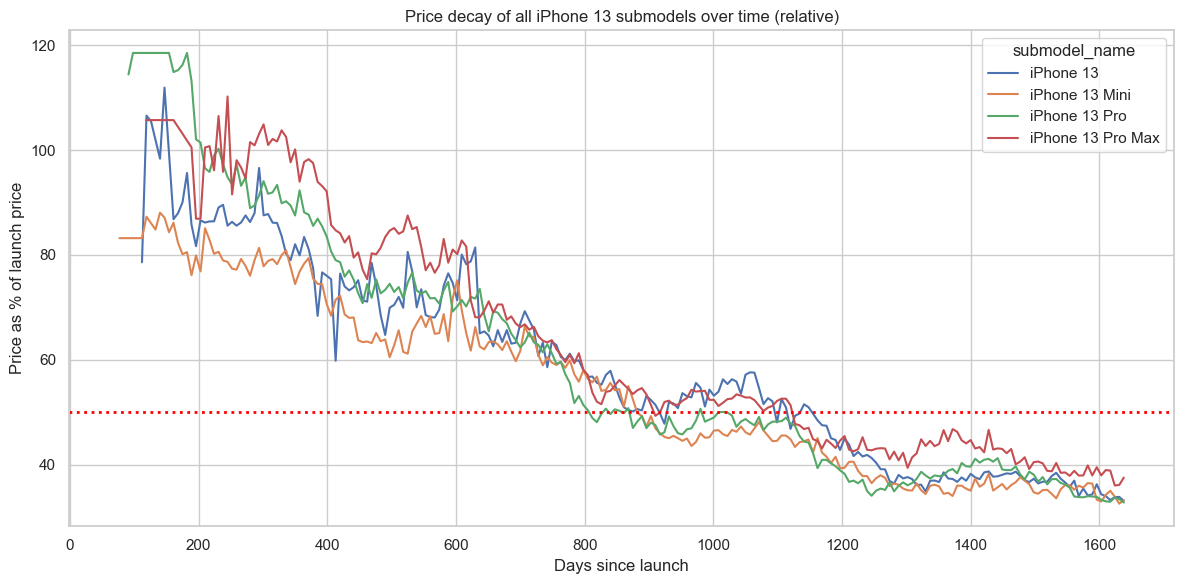

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_2 = sns.lineplot(data=iphone13_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='submodel_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of all iPhone 13 submodels over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()


The Pro Max consistently emerges as the strongest value-retaining version at almost every stage of the lifecycle. Remarkably, it retains roughly 40% of its launch price even at the 1600-day mark.

On the other end of the spectrum, the Mini submodel demonstrates faster depreciation, likely reflecting lower consumer demand and lower popularity on the secondary market.

---
# Brand comparison at one year post-launch

Instead of looking at the full decay curve, this takes a snapshot at around 365 days after
launch and lines up all generations side by side. It's a cleaner way to answer which phones
hold their value best in the first year.

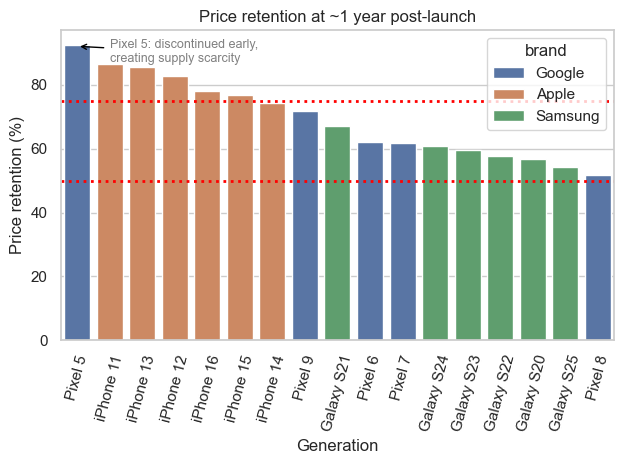

In [10]:
order = retention_1yr_df['generation_name'].tolist()

pd_chart_7 = sns.barplot(
    data=retention_1yr_df,
    x='generation_name',
    y='price_retention',
    hue='brand',
    order=order)

plt.axhline(75, color='red', linestyle='dotted', linewidth=2)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Price retention at ~1 year post-launch')
plt.xlabel('Generation')
plt.ylabel('Price retention (%)')
plt.xticks(rotation=75)
plt.tight_layout()

#Annotation
plt.annotate(
    text = 'Pixel 5: discontinued early,\ncreating supply scarcity',
    xy=(0, 92),
    xytext=(1, 87), color = 'gray',
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9
)

plt.show()


iPhones dominate the top of the chart. The Pixel 5 stands out as an anomaly among Google phones. This could be due to the fact that it launched at a low price ($699) and Google discontinued it earlier than expected, which constrained supply and kept its secondary market value unusually stable. Other Pixel models, which launched at
higher prices and remained available for longer, didn't benefit from that same scarcity effect.

---
# Price distribution across the full lifecycle

The decay curves show averages. This boxplot shows the full spread of weekly prices across
the entire recorded lifecycle for each brand: median, quartiles, and outliers. It gives
a sense of how much variation there is within each brand, not just where the average lands.

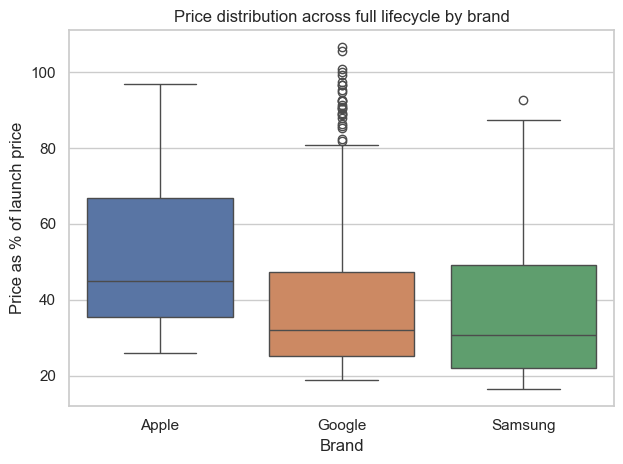

In [11]:
pd_chart_8 = sns.boxplot(
    data=all_brands_decay_df,
    x='brand',
    y='price_pct_of_launch',
    hue='brand')
plt.title('Price distribution across full lifecycle by brand')
plt.xlabel('Brand')
plt.ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()


We can clearly see the Apple products as the highest in terms of median, but also their IQR is placed higher than the competitors. Google and Samsung have very similar plots, with some minor differences, and we can clearly see Google has the highest number of outliers of all three brands.

---
# Sales rank analysis

Amazon's monthly_sold metric is a rank position, not a unit count: lower sales rank (monthly_sold) means the product
is selling more. Keepa only started tracking this consistently from late 2023, so there's only about 2 years of data to work with. The data is limited and I was seriously wondering whether to include it, but it should be enough to see some patterns.

**Sales rank over the product lifecycle for base iPhones**

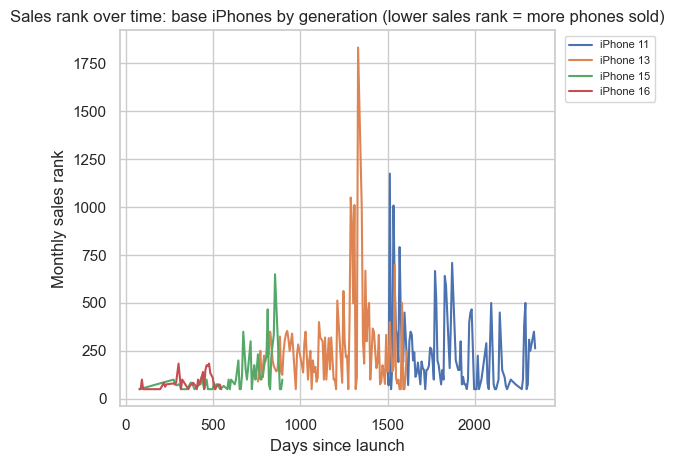

In [12]:
ms_chart_3 = sns.lineplot(
    data=apple_base_rank_df,
    x='days_rounded',
    y='monthly_sold',
    hue='generation_name')

plt.title('Sales rank over time: base iPhones by generation (lower sales rank = more phones sold)')
plt.xlabel('Days since launch')
plt.ylabel('Monthly sales rank')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


An analysis of iPhone sales across multiple generations reveals sustained consumer demand. Notably, older models continue to perform, consistently ranking within the top 50 to 500 product tier. Their sales volume shows clear seasonality, fluctuating within this range.

**Sales rank within a generation for all iPhone 13 and 16 submodels**

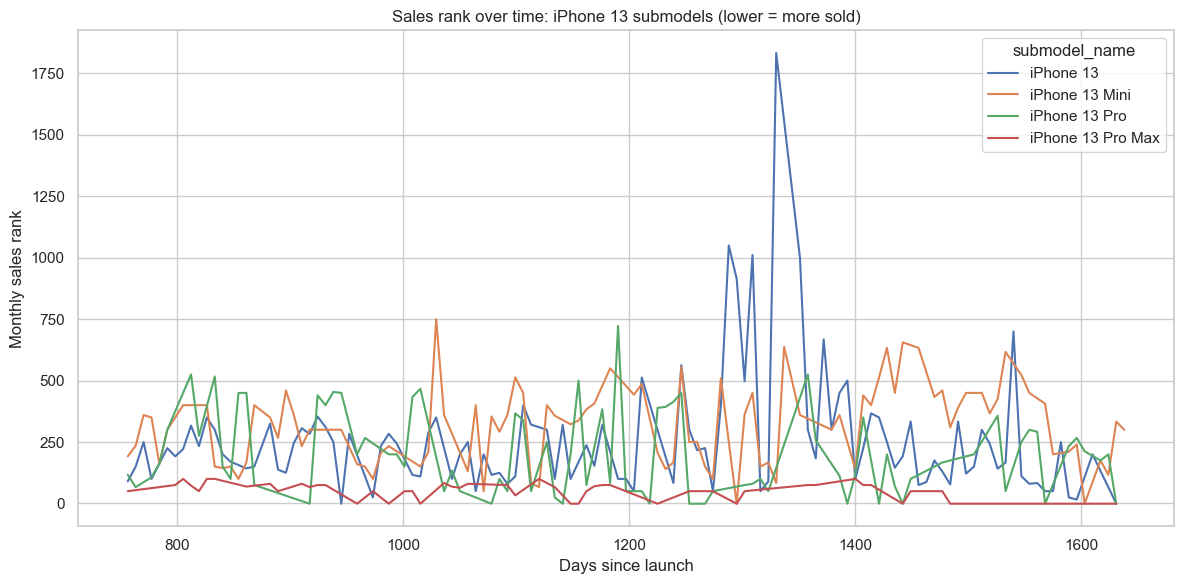

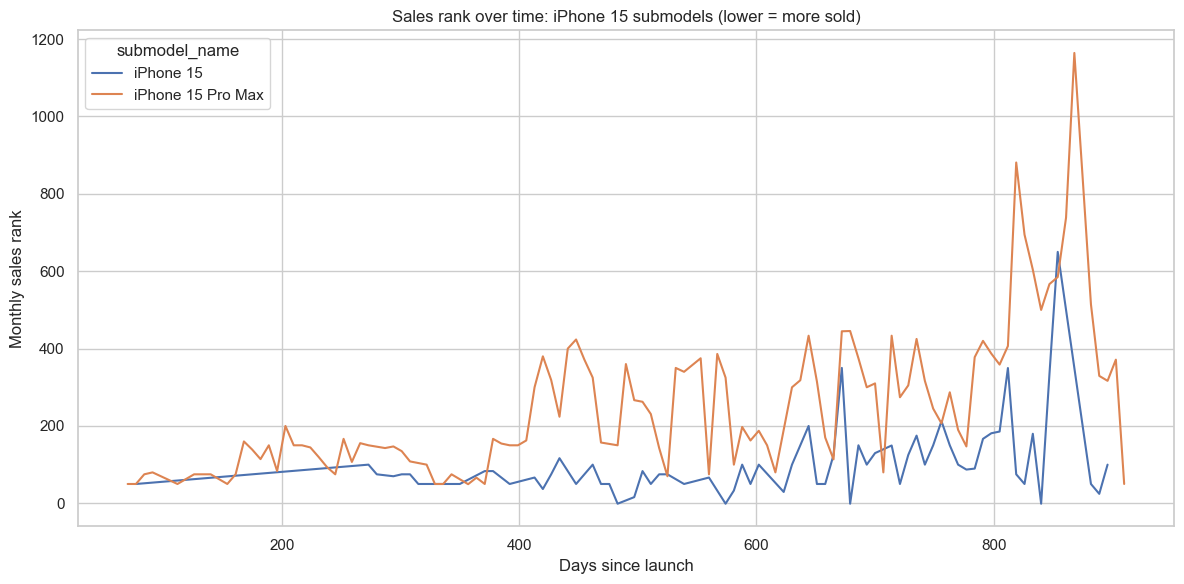

In [13]:
plt.subplots(figsize=(12, 6))

ms_chart_4 = sns.lineplot(
    data=iphone13_rank_df,
    x='days_rounded',
    y='monthly_sold',
    hue='submodel_name')

plt.title('Sales rank over time: iPhone 13 submodels (lower = more sold)')
plt.xlabel('Days since launch')
plt.ylabel('Monthly sales rank')
plt.tight_layout()
plt.show()

plt.subplots(figsize=(12, 6))

ms_chart_5 = sns.lineplot(
    data=iphone15_rank_df,
    x='days_rounded',
    y='monthly_sold',
    hue='submodel_name')

plt.title('Sales rank over time: iPhone 15 submodels (lower = more sold)')
plt.xlabel('Days since launch')
plt.ylabel('Monthly sales rank')
plt.tight_layout()
plt.show()


The Pro Max appears to be the most popular submodel in the iPhone 13 lineup. It might be a bit counterintuitive
at first, as you'd expect the cheaper base model to sell more, but at this stage of the lifecycle
the Pro Max is deeply discounted from its launch price and still offers the best hardware
of the generation. Buyers looking for a budget flagship will often go for the top tier once the
price is right.

Integrating early data from the iPhone 15 highlights initial sales performance. At launch, the base model drives the highest volume, as the Pro Max’s price point creates a high entry barrier. We could expect that in the future it might reflect the pattern found in the iPhone 13 lineup.

**Sales rank on real calendar dates - base iPhones**

Using actual dates rather than days since launch makes it possible to spot seasonal patterns.
Gray dotted lines mark the September iPhone launch window, orange is Black Friday, red is Christmas.
Data starts from late 2023, so there are only two seasonal cycles visible.

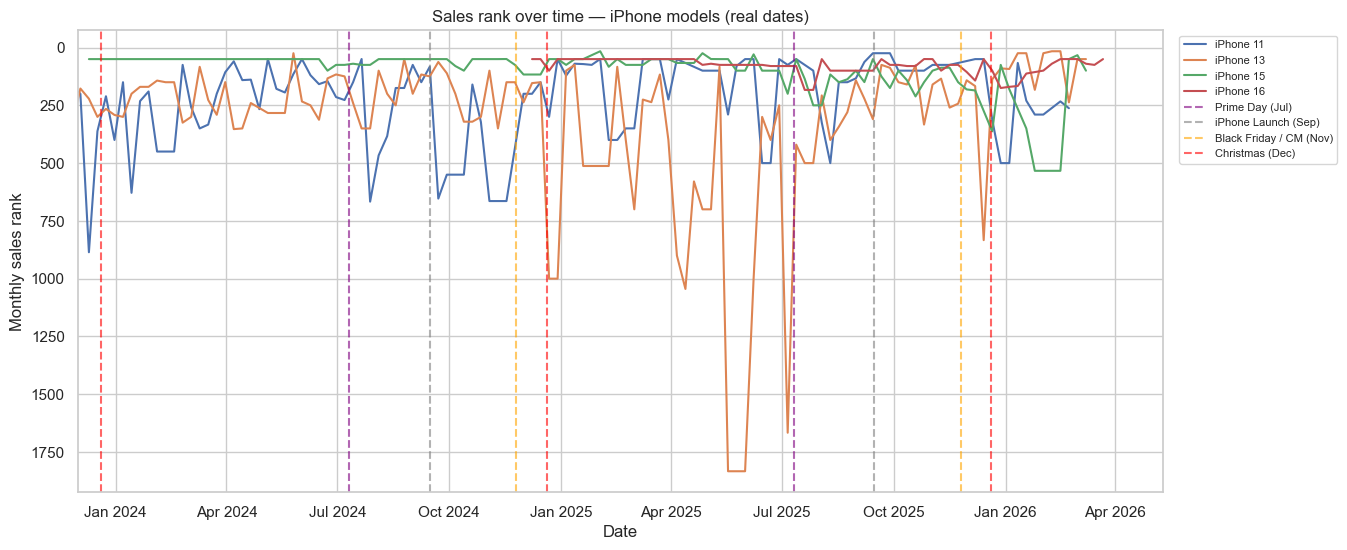

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_5 = sns.lineplot(data=apple_base_rank_dates_df, x='datetime', y='monthly_sold',
    hue='generation_name', ax=ax)
ax.invert_yaxis()

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales rank over time — iPhone models (real dates)')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales rank')
ax.set_xlim(left=pd.Timestamp('2023-12-01'))
plt.show()


1. Despite limited data, the most striking finding is that iPhone demand remains remarkably resilient. Sales maintain a consistently high baseline throughout the entire year.

2. The iPhone 15 maintained high stability until the iPhone 17 launch, which caused a slight dip. Currently, the iPhone 16 is the top performer, marginally outperforming the iPhone 15 with a narrow gap between them.

3. Older generations exhibit much higher volatility, peaking sharply during end-of-year holiday shopping. Despite these fluctuations, they stay strong in the top 500–750 tier, with the iPhone 11 slightly outselling the iPhone 13 as a budget entry point.

**iPhone 13 submodels on real calendar dates**

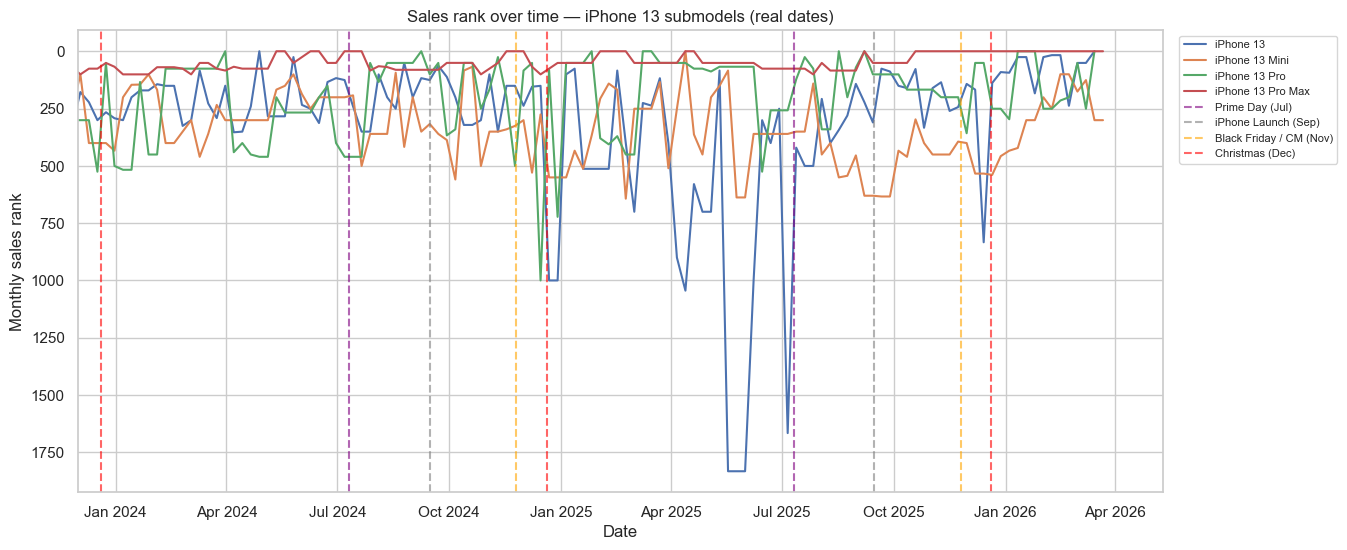

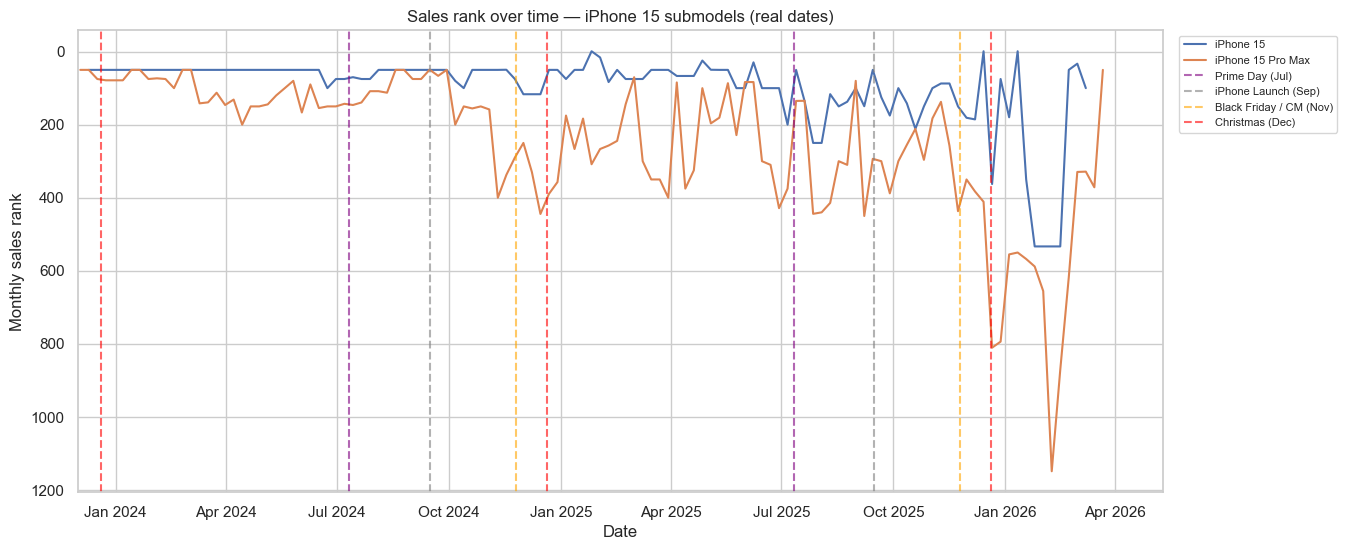

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_6 = sns.lineplot(data=iphone13_rank_dates_df, x='datetime', y='monthly_sold',
    hue='submodel_name', ax=ax)

ax.invert_yaxis()

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales rank over time — iPhone 13 submodels (real dates)')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales rank')
ax.set_xlim(left = pd.Timestamp('2023-12-01'))
plt.show()



fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_7 = sns.lineplot(data=iphone15_rank_dates_df, x='datetime', y='monthly_sold',
    hue='submodel_name', ax=ax)
ax.invert_yaxis()

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales rank over time — iPhone 15 submodels (real dates)')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales rank')
ax.set_xlim(left = pd.Timestamp('2023-12-01'))
plt.show()

Looking at the iPhone 15, we observe a sales decrease for the Pro Max version immediately after the iPhone 16 launch, followed by an even sharper decline after the iPhone 17 release. Interestingly, it has recently begun to regain its market position. Within the iPhone 15 lineup, the Pro Max demonstrates significantly higher volatility compared to the relatively stable base model.

This behavior stands in a visible contrast to the iPhone 13, where the roles are reversed: the Pro Max serves as the stable anchor with consistently high demand throughout the year, while its base counterpart exhibits greater volatility. Nevertheless, despite these shifting dynamics, all examined submodels maintain a high baseline of popularity and remain strongly sought after by consumers.



---
# Key findings

- **Apple retains value best.** At the one-year mark, iPhones hold significantly more of their
  launch price than Samsung or Google. The 50% barrier comes around 900 days for Apple vs
  roughly 500 days for Samsung and 420 for Google.

- **Renewed Premium holds its value better than standard Renewed.** For iPhones the gap
  averages around 10.3 percentage points and stays fairly stable
  throughout the lifecycle. It's not just a launch-window premium.

- **The Pixel 5 is an anomaly.** It outperforms every other Google model at the one-year mark.
  Low launch price plus early discontinuation created supply constraints that kept its
  secondary market value elevated longer than expected.

- **Older flagships attract buyers looking for the best hardware at a discount.** The iPhone 13
  Pro Max shows stronger sales rank than cheaper submodels of the same generation, suggesting
  people actively seek out the top tier once the price drops to a reasonable level. Data shows that the base models sell more at the beginning and Pro Max model sells more later.

- **Seasonal sales data is limited.** The monthly_sold metric only covers from late 2023,
  making it hard to draw firm conclusions about Black Friday, Prime Day, or Christmas effects. There are hints of demand improvement and also some signs of demand decrease after the premieres (e.g. iPhone 15 clean sales decrease after iPhone 16 launched), but it's also evident that iPhones hold a strong demand baseline throughout the year.

